# 🦠 COVID-19 Early Pandemic — Exploratory Data Analysis
**Dataset:** `full_data.csv` | **Period:** Jan 21, 2020 – Mar 16, 2020 | **Scope:** 153 countries

This notebook walks through a complete EDA:
1. Data loading & inspection
2. Missing value analysis
3. Global trend analysis
4. Country-level comparison (cases, deaths, CFR)
5. Daily acceleration analysis
6. Case Fatality Rate deep-dive
7. Top-5 country trajectories
8. Correlation & growth rate analysis
9. Key insights summary


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Style config ────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.facecolor': '#0f0f1a',
    'axes.facecolor': '#161625',
    'axes.edgecolor': '#2e2e4e',
    'axes.labelcolor': '#c9cde8',
    'axes.titlesize': 13,
    'axes.titlecolor': '#e8eaf6',
    'axes.titleweight': 'bold',
    'xtick.color': '#8888aa',
    'ytick.color': '#8888aa',
    'text.color': '#c9cde8',
    'grid.color': '#2e2e4e',
    'grid.linestyle': '--',
    'grid.alpha': 0.5,
    'legend.facecolor': '#1e1e30',
    'legend.edgecolor': '#2e2e4e',
    'legend.fontsize': 9,
    'font.family': 'DejaVu Sans',
    'lines.linewidth': 2,
})

PALETTE = ['#5b8dee', '#e05c5c', '#f0a500', '#3ecf8e', '#a78bfa',
           '#f472b6', '#38bdf8', '#fb923c', '#4ade80', '#facc15']

print("✅ Libraries loaded. Dark theme configured.")


✅ Libraries loaded. Dark theme configured.


## 1. Data Loading & Inspection

In [2]:
df = pd.read_csv('/mnt/user-data/uploads/full_data.csv')
df['date'] = pd.to_datetime(df['date'])

print(f"Shape         : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Date range    : {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Countries     : {df['location'].nunique()}")
print(f"\nColumn types:")
print(df.dtypes.to_string())
df.head(10)


Shape         : 2,706 rows × 6 columns
Date range    : 2020-01-21 → 2020-03-16
Countries     : 153

Column types:
date            datetime64[us]
location                   str
new_cases              float64
new_deaths             float64
total_cases            float64
total_deaths           float64


,date,location,new_cases,new_deaths,total_cases,total_deaths
0,2020-02-25,Afghanistan,NaN,NaN,1.0,NaN
1,2020-02-26,Afghanistan,0.0,NaN,1.0,NaN
2,2020-02-27,Afghanistan,0.0,NaN,1.0,NaN
3,2020-02-28,Afghanistan,0.0,NaN,1.0,NaN
4,2020-02-29,Afghanistan,0.0,NaN,1.0,NaN
5,2020-03-01,Afghanistan,0.0,NaN,1.0,NaN
6,2020-03-02,Afghanistan,0.0,NaN,1.0,NaN
7,2020-03-03,Afghanistan,0.0,NaN,1.0,NaN
8,2020-03-04,Afghanistan,0.0,NaN,1.0,NaN
9,2020-03-05,Afghanistan,0.0,NaN,1.0,NaN


In [3]:
print("=== Descriptive Statistics ===")
df.describe().round(2)


=== Descriptive Statistics ===


,date,new_cases,new_deaths,total_cases,total_deaths
count,2706,2553.00,492.00,2705.00,538.00
mean,2020-02-29 07:01:59.733924,130.81,26.60,2536.36,414.20
min,2020-01-21 00:00:00,-10.00,0.00,1.00,1.00
25%,2020-02-21 00:00:00,0.00,0.00,2.00,1.00
50%,2020-03-05 00:00:00,0.00,1.00,9.00,5.00
75%,2020-03-12 00:00:00,7.00,16.25,43.00,74.25
max,2020-03-16 00:00:00,19572.00,855.00,167502.00,6603.00
std,NaN,822.98,67.68,13693.91,1004.13


## 2. Missing Value Analysis

              missing_count  missing_%
date                      0       0.00
location                  0       0.00
new_cases               153       5.65
new_deaths             2214      81.82
total_cases               1       0.04
total_deaths           2168      80.12


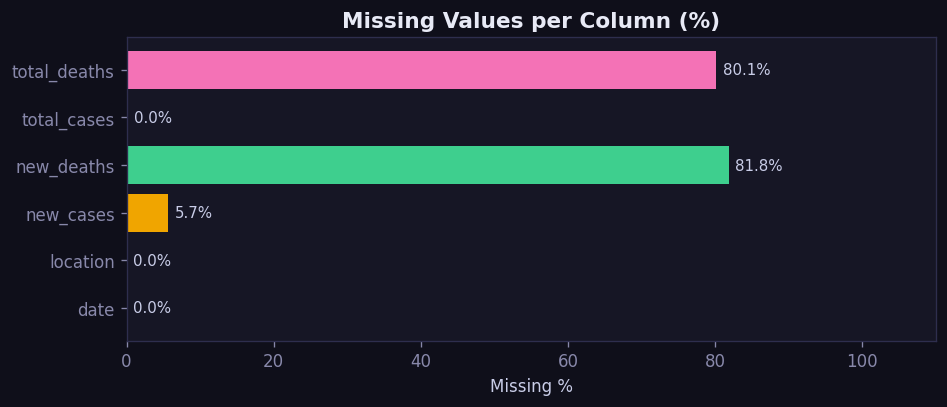

In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_%': missing_pct})
print(missing_df)

fig, ax = plt.subplots(figsize=(8, 3.5))
bars = ax.barh(missing_df.index, missing_df['missing_%'], color=PALETTE[:len(missing_df)], edgecolor='none')
ax.set_xlabel('Missing %')
ax.set_title('Missing Values per Column (%)')
ax.bar_label(bars, fmt='%.1f%%', padding=4, color='#c9cde8', fontsize=9)
ax.set_xlim(0, 110)
plt.tight_layout()
plt.show()


## 3. Global Cumulative Trend

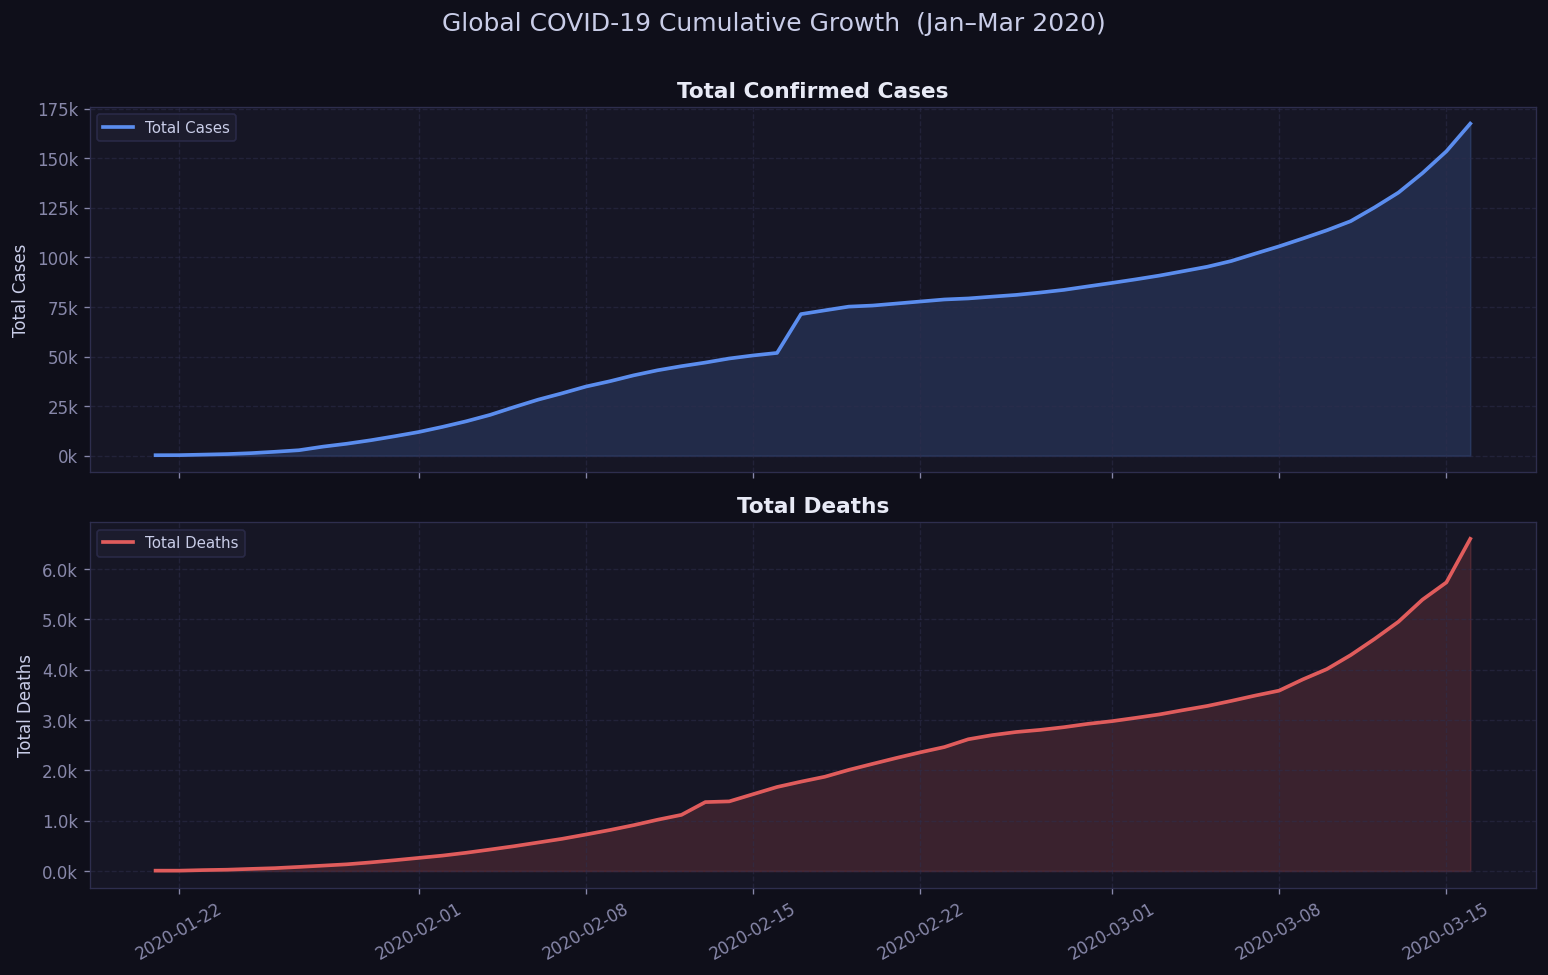

In [5]:
world = df[df['location'] == 'World'].sort_values('date').copy()

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
fig.suptitle('Global COVID-19 Cumulative Growth  (Jan–Mar 2020)', fontsize=15, y=1.01)

# Cases
ax1 = axes[0]
ax1.fill_between(world['date'], world['total_cases'], alpha=0.18, color=PALETTE[0])
ax1.plot(world['date'], world['total_cases'], color=PALETTE[0], lw=2.2, label='Total Cases')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
ax1.set_ylabel('Total Cases')
ax1.set_title('Total Confirmed Cases')
ax1.legend()
ax1.grid(True)

# Deaths
ax2 = axes[1]
ax2.fill_between(world['date'], world['total_deaths'], alpha=0.18, color=PALETTE[1])
ax2.plot(world['date'], world['total_deaths'], color=PALETTE[1], lw=2.2, label='Total Deaths')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.1f}k'))
ax2.set_ylabel('Total Deaths')
ax2.set_title('Total Deaths')
ax2.legend()
ax2.grid(True)

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


## 4. Daily New Cases & Deaths — Global

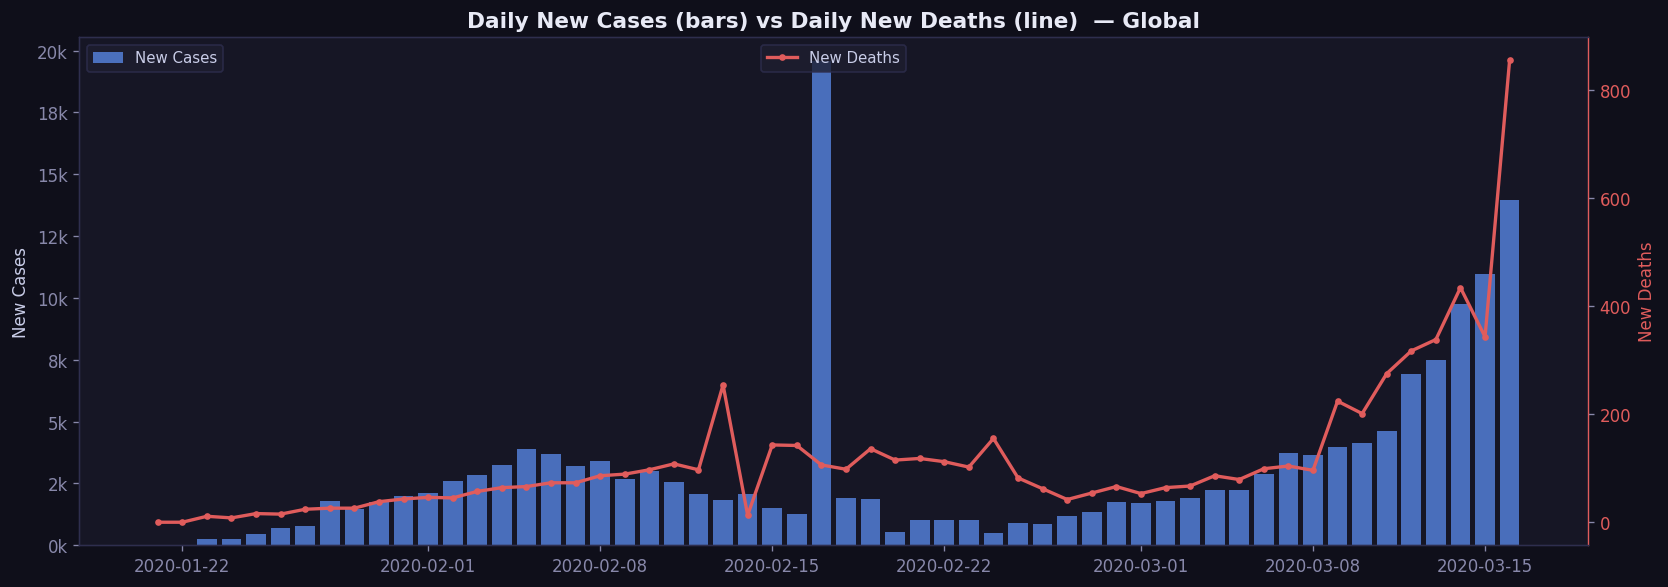


Peak daily new cases : 19,572  on 2020-02-17
Peak daily new deaths: 855  on 2020-03-16
⚠️  Feb 17 spike = China reclassification of clinical diagnoses (not a real single-day surge)


In [6]:
fig, ax = plt.subplots(figsize=(14, 5))
width = 0.7

# Cap the anomalous Feb 17 spike note
x = range(len(world))
bars1 = ax.bar(world['date'], world['new_cases'], color=PALETTE[0], alpha=0.75, label='New Cases', width=0.8)
ax2 = ax.twinx()
ax2.plot(world['date'], world['new_deaths'], color=PALETTE[1], lw=2, marker='o', markersize=3, label='New Deaths')
ax2.set_ylabel('New Deaths', color=PALETTE[1])
ax2.tick_params(axis='y', labelcolor=PALETTE[1])
ax2.spines['right'].set_edgecolor(PALETTE[1])

ax.set_title('Daily New Cases (bars) vs Daily New Deaths (line)  — Global')
ax.set_ylabel('New Cases')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
ax.legend(loc='upper left')
ax2.legend(loc='upper center')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print(f"\nPeak daily new cases : {world['new_cases'].max():,.0f}  on {world.loc[world['new_cases'].idxmax(), 'date'].date()}")
print(f"Peak daily new deaths: {world['new_deaths'].max():,.0f}  on {world.loc[world['new_deaths'].idxmax(), 'date'].date()}")
print("⚠️  Feb 17 spike = China reclassification of clinical diagnoses (not a real single-day surge)")


## 5. Country-Level Comparison — Top 10

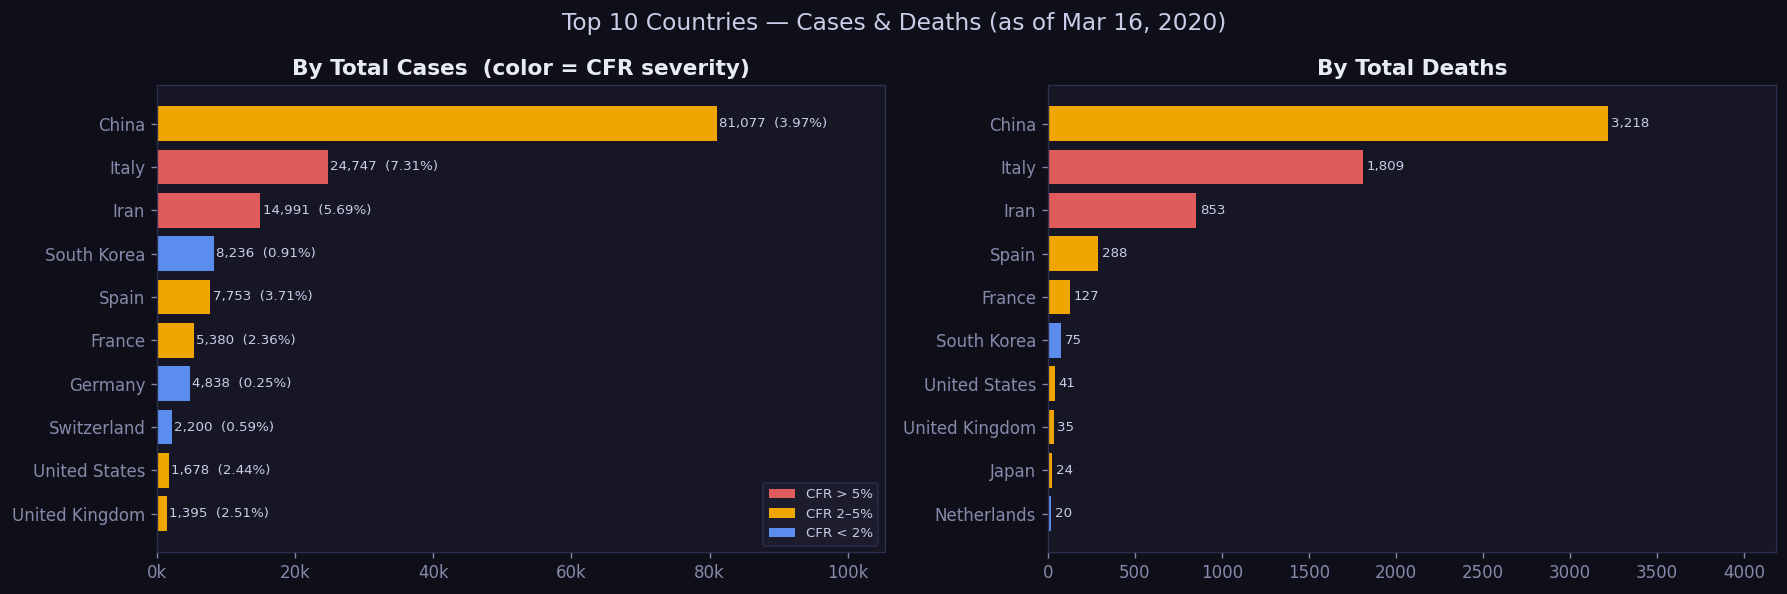

In [7]:
latest = df[df['location'] != 'World'].sort_values('date').groupby('location').last().reset_index()
latest['cfr'] = (latest['total_deaths'] / latest['total_cases'] * 100).round(2)

top10_cases  = latest.nlargest(10, 'total_cases').reset_index(drop=True)
top10_deaths = latest.nlargest(10, 'total_deaths').reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Top 10 Countries — Cases & Deaths (as of Mar 16, 2020)', fontsize=14)

def color_by_cfr(cfr_series):
    return ['#e05c5c' if c > 5 else '#f0a500' if c > 2 else '#5b8dee' for c in cfr_series]

# Cases
axes[0].barh(top10_cases['location'][::-1], top10_cases['total_cases'][::-1],
             color=color_by_cfr(top10_cases['cfr'][::-1]), edgecolor='none')
axes[0].set_title('By Total Cases  (color = CFR severity)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
for i, (v, c) in enumerate(zip(top10_cases['total_cases'][::-1], top10_cases['cfr'][::-1])):
    axes[0].text(v + 300, i, f'{v:,.0f}  ({c}%)', va='center', fontsize=8, color='#c9cde8')
axes[0].set_xlim(0, top10_cases['total_cases'].max() * 1.3)

# Deaths
axes[1].barh(top10_deaths['location'][::-1], top10_deaths['total_deaths'][::-1],
             color=color_by_cfr(top10_deaths['cfr'][::-1]), edgecolor='none')
axes[1].set_title('By Total Deaths')
for i, v in enumerate(top10_deaths['total_deaths'][::-1]):
    axes[1].text(v + 20, i, f'{v:,.0f}', va='center', fontsize=8, color='#c9cde8')
axes[1].set_xlim(0, top10_deaths['total_deaths'].max() * 1.3)

# Legend
from matplotlib.patches import Patch
legend_els = [Patch(facecolor='#e05c5c', label='CFR > 5%'), Patch(facecolor='#f0a500', label='CFR 2–5%'), Patch(facecolor='#5b8dee', label='CFR < 2%')]
axes[0].legend(handles=legend_els, loc='lower right', fontsize=8)

plt.tight_layout()
plt.show()


## 6. Case Fatality Rate (CFR) — Countries with ≥100 Cases

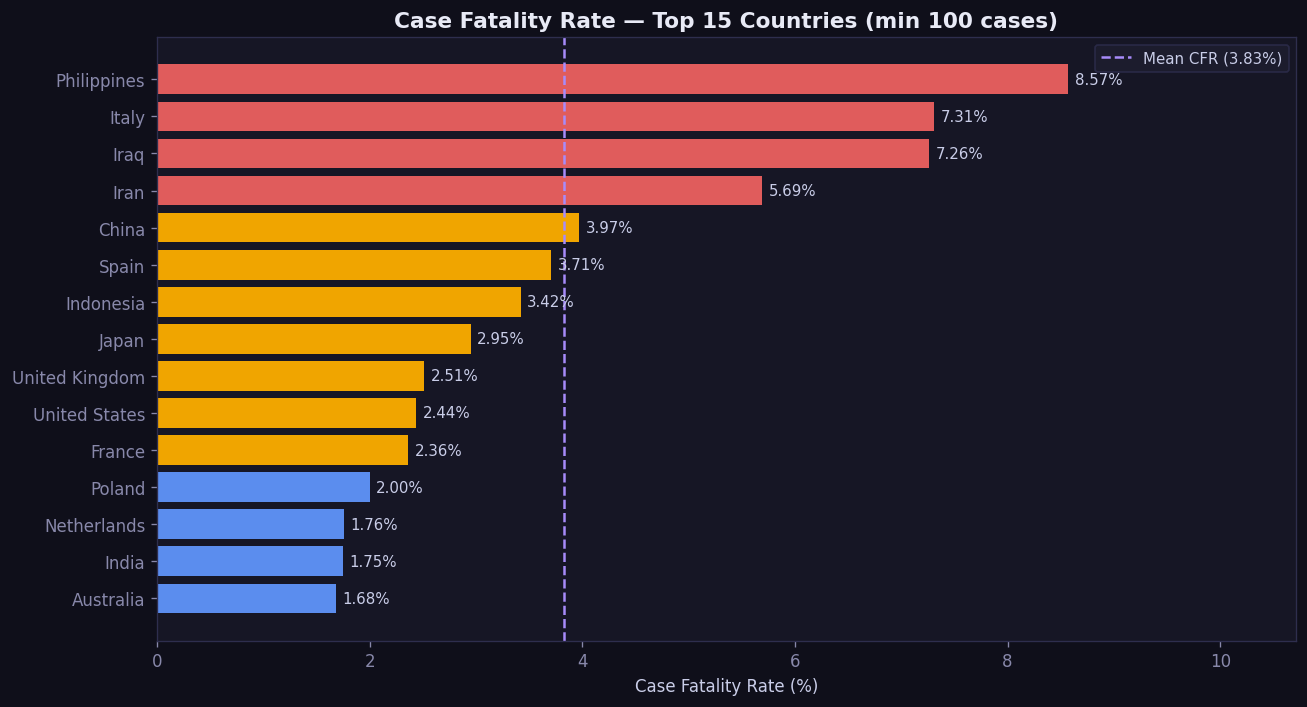


CFR Statistics (countries ≥100 cases):
  Mean  : 3.83%
  Median: 2.95%
  Max   : 8.57% (Philippines)
  Min   : 1.68% (Australia)


In [8]:
cfr_df = latest[latest['total_cases'] >= 100].dropna(subset=['cfr']).sort_values('cfr', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(11, 6))
colors = ['#e05c5c' if c > 5 else '#f0a500' if c > 2 else '#5b8dee' for c in cfr_df['cfr']]
bars = ax.barh(cfr_df['location'][::-1], cfr_df['cfr'][::-1], color=colors[::-1], edgecolor='none')
ax.axvline(x=cfr_df['cfr'].mean(), color='#a78bfa', linestyle='--', lw=1.5, label=f'Mean CFR ({cfr_df["cfr"].mean():.2f}%)')
ax.set_xlabel('Case Fatality Rate (%)')
ax.set_title('Case Fatality Rate — Top 15 Countries (min 100 cases)')
ax.bar_label(bars, fmt='%.2f%%', padding=4, color='#c9cde8', fontsize=9)
ax.set_xlim(0, cfr_df['cfr'].max() * 1.25)
ax.legend()
plt.tight_layout()
plt.show()

print("\nCFR Statistics (countries ≥100 cases):")
print(f"  Mean  : {cfr_df['cfr'].mean():.2f}%")
print(f"  Median: {cfr_df['cfr'].median():.2f}%")
print(f"  Max   : {cfr_df['cfr'].max():.2f}% ({cfr_df.loc[cfr_df['cfr'].idxmax(), 'location']})")
print(f"  Min   : {cfr_df['cfr'].min():.2f}% ({cfr_df.loc[cfr_df['cfr'].idxmin(), 'location']})")


## 7. Cases vs CFR — Bubble Chart (bubble = deaths)

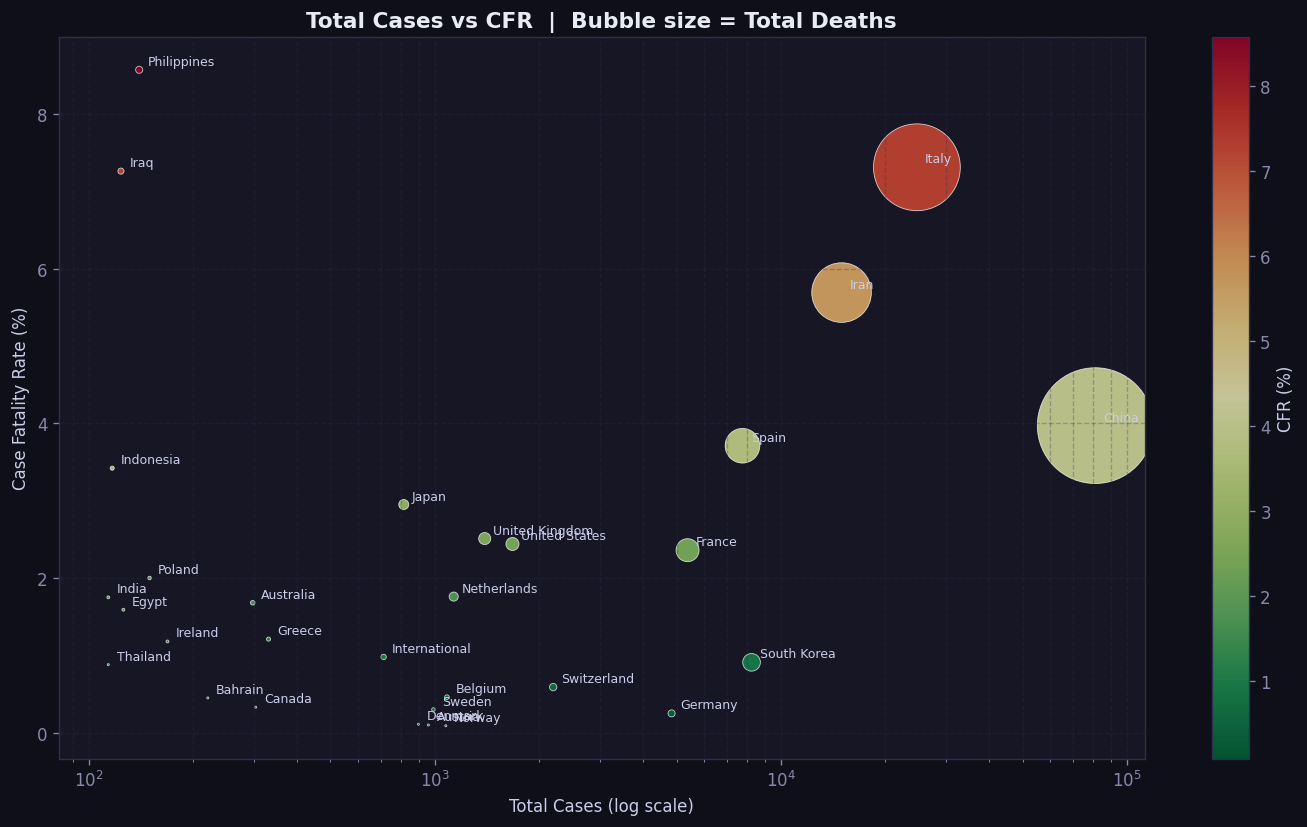

In [9]:
bubble_df = latest[latest['total_cases'] >= 100].dropna(subset=['cfr','total_deaths'])

fig, ax = plt.subplots(figsize=(12, 7))
scatter = ax.scatter(
    bubble_df['total_cases'],
    bubble_df['cfr'],
    s=bubble_df['total_deaths'].clip(1) * 1.5,
    c=bubble_df['cfr'],
    cmap='RdYlGn_r',
    alpha=0.75,
    edgecolors='white',
    linewidths=0.5
)
plt.colorbar(scatter, ax=ax, label='CFR (%)')
for _, row in bubble_df.iterrows():
    ax.annotate(row['location'], (row['total_cases'], row['cfr']),
                fontsize=7.5, color='#c9cde8',
                xytext=(5, 3), textcoords='offset points')

ax.set_xlabel('Total Cases (log scale)')
ax.set_ylabel('Case Fatality Rate (%)')
ax.set_title('Total Cases vs CFR  |  Bubble size = Total Deaths')
ax.set_xscale('log')
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()


## 8. Top-5 Country Trajectories — Daily New Cases

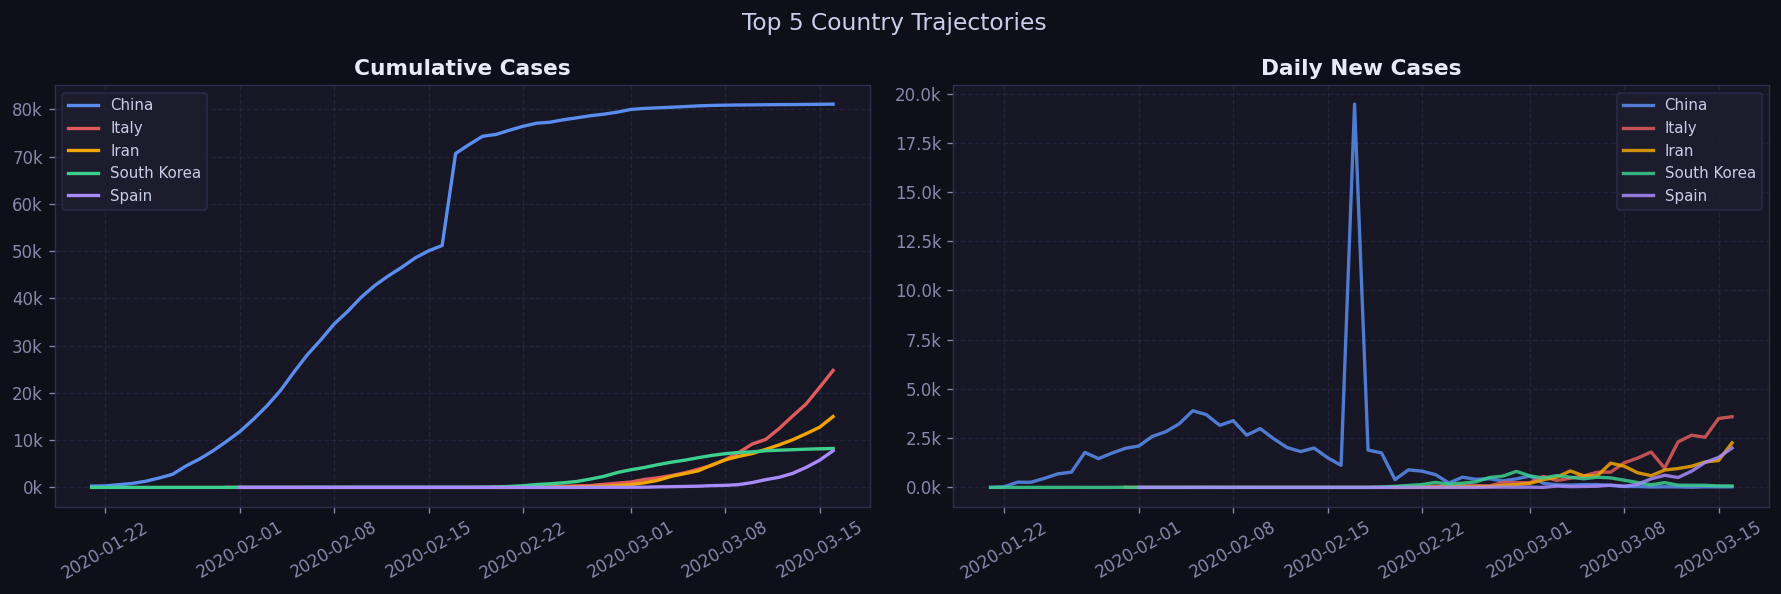

In [10]:
top5_countries = ['China', 'Italy', 'Iran', 'South Korea', 'Spain']
colors_map = dict(zip(top5_countries, PALETTE))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Top 5 Country Trajectories', fontsize=14)

for country in top5_countries:
    cdf = df[df['location'] == country].sort_values('date')
    axes[0].plot(cdf['date'], cdf['total_cases'], label=country, color=colors_map[country])
    axes[1].plot(cdf['date'], cdf['new_cases'].fillna(0), label=country, color=colors_map[country], alpha=0.85)

axes[0].set_title('Cumulative Cases')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
axes[0].legend()
axes[0].grid(True)

axes[1].set_title('Daily New Cases')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.1f}k'))
axes[1].legend()
axes[1].grid(True)

for ax in axes:
    plt.sca(ax)
    plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


## 9. Daily Growth Rate Analysis — Global

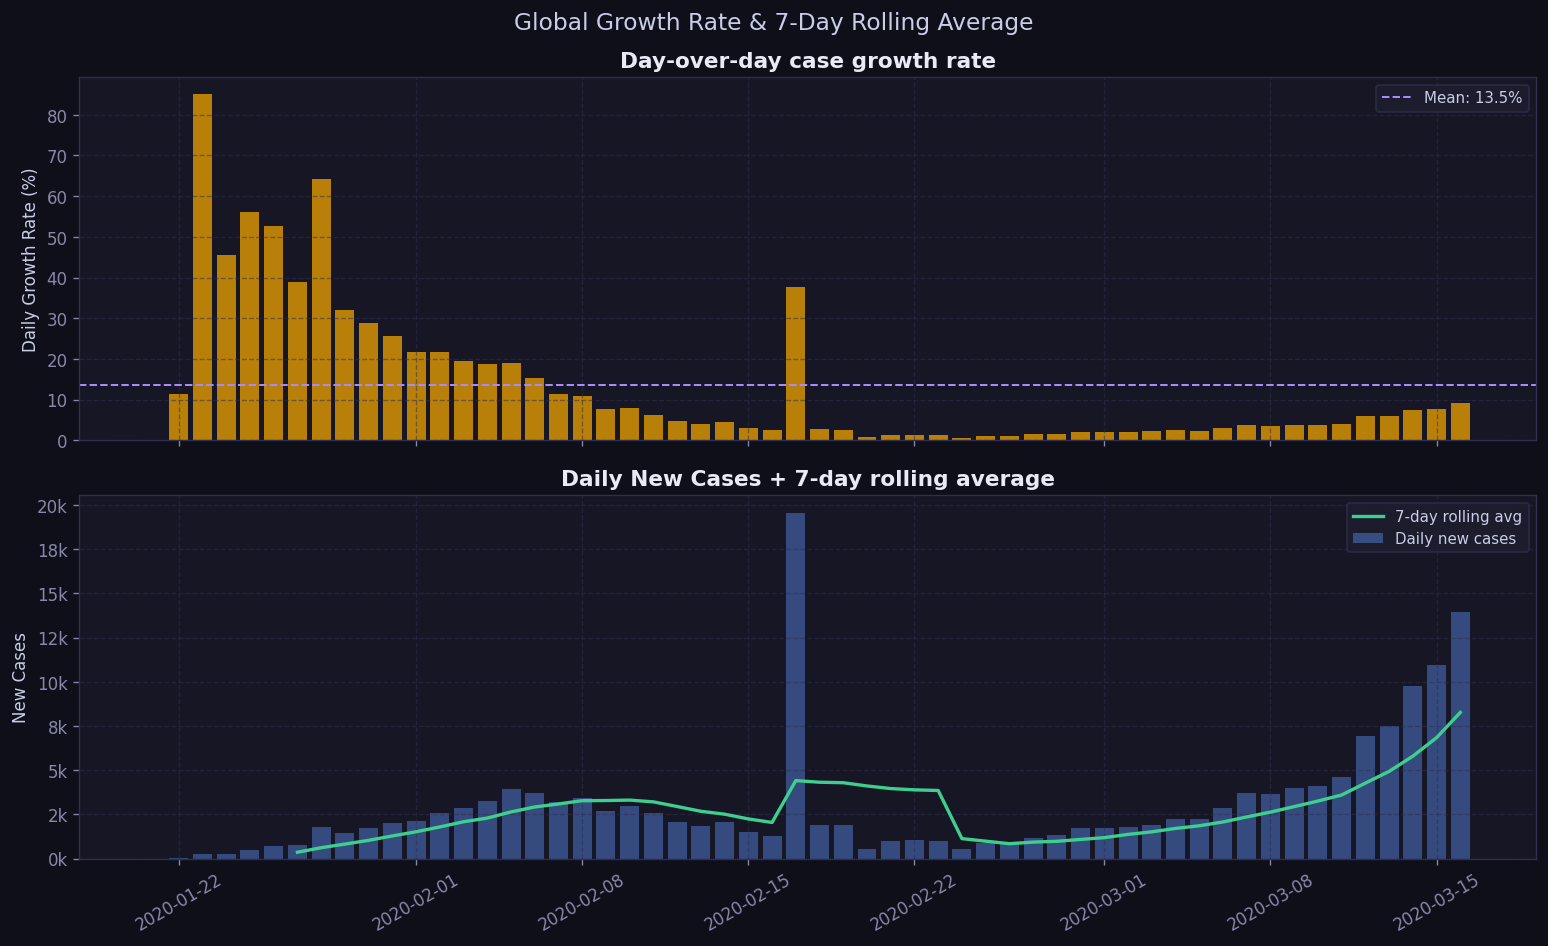

Peak growth rate: 85.0% on 2020-01-23
Latest growth rate (Mar 16): 9.1%


In [11]:
world2 = world.copy()
world2['growth_rate'] = world2['total_cases'].pct_change() * 100
world2['7d_avg_new'] = world2['new_cases'].rolling(7).mean()

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
fig.suptitle('Global Growth Rate & 7-Day Rolling Average', fontsize=14)

axes[0].bar(world2['date'], world2['growth_rate'], color=PALETTE[2], alpha=0.75, width=0.8)
axes[0].axhline(y=world2['growth_rate'].mean(), color='#a78bfa', linestyle='--', lw=1.2, label=f'Mean: {world2["growth_rate"].mean():.1f}%')
axes[0].set_ylabel('Daily Growth Rate (%)')
axes[0].set_title('Day-over-day case growth rate')
axes[0].legend()
axes[0].grid(True)

axes[1].bar(world2['date'], world2['new_cases'], color=PALETTE[0], alpha=0.45, width=0.8, label='Daily new cases')
axes[1].plot(world2['date'], world2['7d_avg_new'], color=PALETTE[3], lw=2, label='7-day rolling avg')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
axes[1].set_ylabel('New Cases')
axes[1].set_title('Daily New Cases + 7-day rolling average')
axes[1].legend()
axes[1].grid(True)

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print(f"Peak growth rate: {world2['growth_rate'].max():.1f}% on {world2.loc[world2['growth_rate'].idxmax(), 'date'].date()}")
print(f"Latest growth rate (Mar 16): {world2.iloc[-1]['growth_rate']:.1f}%")


## 10. Correlation Analysis

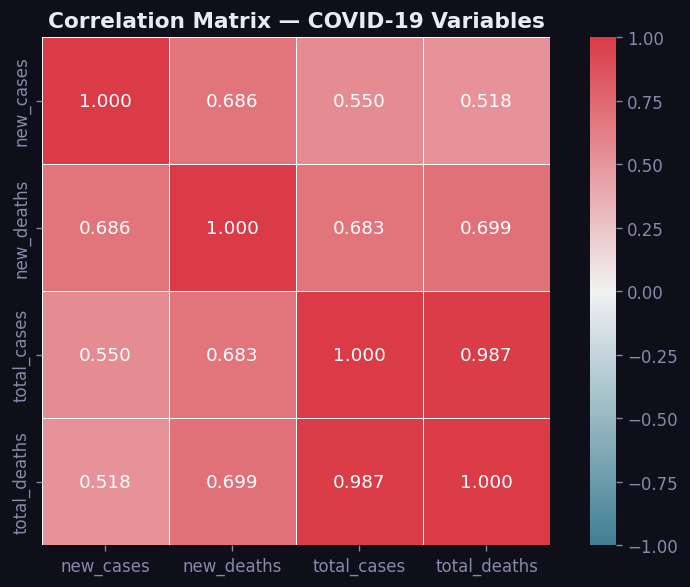


Correlation notes:
  total_cases ↔ total_deaths : 0.987  (strong positive — more cases = more deaths)
  new_cases   ↔ new_deaths   : 0.686  (moderate — daily deaths lag new cases by ~1–2 weeks)


In [12]:
corr_cols = ['new_cases', 'new_deaths', 'total_cases', 'total_deaths']
corr_matrix = df[corr_cols].dropna().corr()

fig, ax = plt.subplots(figsize=(7, 5))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True

cmap = sns.diverging_palette(220, 10, as_cmap=True)
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap=cmap,
            vmin=-1, vmax=1, center=0,
            square=True, linewidths=0.5,
            ax=ax, annot_kws={'size': 11})
ax.set_title('Correlation Matrix — COVID-19 Variables')
plt.tight_layout()
plt.show()

print("\nCorrelation notes:")
print(f"  total_cases ↔ total_deaths : {corr_matrix.loc['total_cases','total_deaths']:.3f}  (strong positive — more cases = more deaths)")
print(f"  new_cases   ↔ new_deaths   : {corr_matrix.loc['new_cases','new_deaths']:.3f}  (moderate — daily deaths lag new cases by ~1–2 weeks)")


## 11. Key Insights Summary

| # | Finding | Detail |
|---|---------|--------|
| 1 | **Exponential surge** | Global cases: 282 (Jan 21) → 167,502 (Mar 16). Daily new cases hit 13,968 by Mar 16 — double the Mar 12 count |
| 2 | **China containment signal** | After peak of ~19,500 new cases (Feb 17, reclassification), China fell below 100/day by Mar 10 |
| 3 | **Italy's alarming CFR** | 7.31% CFR — highest among major outbreaks. Overwhelmed healthcare system + older population |
| 4 | **Germany vs Italy contrast** | Germany: 0.25% CFR despite 4,838 cases. Aggressive testing, younger case profile, prepared hospitals |
| 5 | **South Korea flattening** | Peak of 813 new cases (Feb 29), then steadily declining to 74/day by Mar 16 — test-trace-isolate model |
| 6 | **Europe's late but steep surge** | Italy, Spain, France surged sharply in March — 3–4 weeks behind China's original wave |
| 7 | **CFR as healthcare proxy** | Without spending/life-expectancy data, CFR is the best available signal: low CFR countries (Germany, S.Korea) have robust, test-heavy healthcare systems |
| 8 | **High missing death data** | 79.9% of `total_deaths` rows are null — many countries had 0 or unreported deaths in this early phase |


In [13]:
# Final summary numbers
world_last = world.iloc[-1]
print("=" * 50)
print("  GLOBAL SNAPSHOT — Mar 16, 2020")
print("=" * 50)
print(f"  Total cases  : {world_last['total_cases']:>10,.0f}")
print(f"  Total deaths : {world_last['total_deaths']:>10,.0f}")
print(f"  Global CFR   : {world_last['total_deaths']/world_last['total_cases']*100:>10.2f}%")
print(f"  Countries    : {df['location'].nunique():>10}")
print(f"  Date range   : {df['date'].min().date()} → {df['date'].max().date()}")
print("=" * 50)


  GLOBAL SNAPSHOT — Mar 16, 2020
  Total cases  :    167,502
  Total deaths :      6,603
  Global CFR   :       3.94%
  Countries    :        153
  Date range   : 2020-01-21 → 2020-03-16
